# Forest Cover Type Classification

Luca Mongiello & Xiaojun Liang

Supervised multiclass classification of forest cover type (7 classes) on the UCI **Covertype** dataset (N = 581,012, p = 54), using Spark MLlib on a 2-node cluster (1 master + 1 worker), with data on **HDFS** and Spark running on **YARN**.

---

## Environment and required library versions

| Component   | Version |
|-------------|---------|
| Spark       | 4.1.2   |
| Hadoop      | 3.5.0   |
| Java        | 17      |
| Python      | 3.12.3  |
| pyspark     | 4.1.2   |
| pandas      | 3.0.5   |
| numpy       | 2.5.2   |
| matplotlib  | 3.11.1  |
| seaborn     | 0.13.2  |

## 1. Configuration

In [1]:
# --- Spark ---
SPARK_MASTER       = "yarn"
DEPLOY_MODE        = "client"
APP_NAME           = "covertype"
DRIVER_MEMORY      = "1g"        
EXECUTOR_INSTANCES = 1
EXECUTOR_CORES     = 4
EXECUTOR_MEMORY    = "6g"
EXECUTOR_OVERHEAD  = "1g"  
AM_MEMORY          = "512m"      
SHUFFLE_PARTITIONS = 8

# --- HDFS ---
HDFS_DIR  = "hdfs:///user/vagrant/covtype"
HDFS_RAW  = HDFS_DIR + "/covtype.data.gz"
LOCAL_RAW = "/home/vagrant/covtype.data.gz"
DATA_URL  = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz"

# --- Reproducibility and splits ---
SEED       = 42
TRAIN_FRAC = 0.8

In [2]:
# --- Imports ---
import os
import subprocess
from urllib import request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation
from pyspark.ml.classification import (
    DecisionTreeClassifier, RandomForestClassifier,
    GBTClassifier, MultilayerPerceptronClassifier, OneVsRest,
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

## 2. SparkSession

In [3]:
spark = (
    SparkSession.builder
    .appName(APP_NAME)
    .master(SPARK_MASTER)
    .config("spark.submit.deployMode",      DEPLOY_MODE)
    .config("spark.executor.instances",     EXECUTOR_INSTANCES)
    .config("spark.executor.cores",         EXECUTOR_CORES)
    .config("spark.executor.memory",        EXECUTOR_MEMORY)
    .config("spark.executor.memoryOverhead",EXECUTOR_OVERHEAD)
    .config("spark.yarn.am.memory",         AM_MEMORY)
    .config("spark.driver.memory",          DRIVER_MEMORY)
    .config("spark.sql.shuffle.partitions", SHUFFLE_PARTITIONS)
    .config("spark.ui.showConsoleProgress", "false")
    .config("spark.sql.debug.maxToStringFields", 100)
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/05 14:32:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/05 14:32:37 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.


## 3. Data acquisition

In [4]:
os.environ["HADOOP_ROOT_LOGGER"] = "ERROR,console"

def hdfs_exists(path: str) -> bool:
    return subprocess.run(["hdfs", "dfs", "-test", "-e", path],
                          capture_output=True).returncode == 0

def sh(cmd: list[str]) -> None:
    print("+", " ".join(cmd))
    subprocess.run(cmd, check=True)

if hdfs_exists(HDFS_RAW):
    print("Already on HDFS:", HDFS_RAW)
else:
    if not os.path.exists(LOCAL_RAW):
        print("Downloading:", DATA_URL)
        request.urlretrieve(DATA_URL, LOCAL_RAW)
        print("Saved to:", LOCAL_RAW)
    sh(["hdfs", "dfs", "-mkdir", "-p", HDFS_DIR])
    sh(["hdfs", "dfs", "-put", "-f", LOCAL_RAW, HDFS_RAW])
    print("Uploaded to HDFS:", HDFS_RAW)

sh(["hdfs", "dfs", "-ls", HDFS_DIR])

Already on HDFS: hdfs:///user/vagrant/covtype/covtype.data.gz
+ hdfs dfs -ls hdfs:///user/vagrant/covtype
Found 1 items
-rw-r--r--   1 vagrant supergroup   11240707 2026-08-31 13:21 hdfs:///user/vagrant/covtype/covtype.data.gz


## 4. Schema definition and data loading

In [5]:
# --- Column groups ---
QUANTITATIVE = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
]                                                             # 10 quantitative
WILDERNESS = [f"Wilderness_Area_{i}" for i in range(1, 5)]    # 4 binary
SOIL       = [f"Soil_Type_{i}"       for i in range(1, 41)]   # 40 binary
LABEL      = "Cover_Type"                                     # target (1..7)
N_CLASSES  = 7
CLASSES    = [f"C{i}" for i in range(1, N_CLASSES + 1)]       # display labels

FEATURE_COLS = QUANTITATIVE + WILDERNESS + SOIL
ALL_COLS     = FEATURE_COLS + [LABEL]

schema = StructType([
    StructField(name, IntegerType()) for name in ALL_COLS
])

In [6]:
df = (
    spark.read
    .schema(schema)
    .option("header", "false")
    .csv(HDFS_RAW)
    .repartition(SHUFFLE_PARTITIONS)
    .cache()
)

print(f"Rows: {df.count():,}")

Rows: 581,012


In [7]:
df.printSchema()
df.select(QUANTITATIVE + [LABEL]).limit(5).toPandas()

root
 |-- Elevation: integer (nullable = true)
 |-- Aspect: integer (nullable = true)
 |-- Slope: integer (nullable = true)
 |-- Horizontal_Distance_To_Hydrology: integer (nullable = true)
 |-- Vertical_Distance_To_Hydrology: integer (nullable = true)
 |-- Horizontal_Distance_To_Roadways: integer (nullable = true)
 |-- Hillshade_9am: integer (nullable = true)
 |-- Hillshade_Noon: integer (nullable = true)
 |-- Hillshade_3pm: integer (nullable = true)
 |-- Horizontal_Distance_To_Fire_Points: integer (nullable = true)
 |-- Wilderness_Area_1: integer (nullable = true)
 |-- Wilderness_Area_2: integer (nullable = true)
 |-- Wilderness_Area_3: integer (nullable = true)
 |-- Wilderness_Area_4: integer (nullable = true)
 |-- Soil_Type_1: integer (nullable = true)
 |-- Soil_Type_2: integer (nullable = true)
 |-- Soil_Type_3: integer (nullable = true)
 |-- Soil_Type_4: integer (nullable = true)
 |-- Soil_Type_5: integer (nullable = true)
 |-- Soil_Type_6: integer (nullable = true)
 |-- Soil_Type

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type
0,3172,152,18,426,59,3521,239,237,120,3302,2
1,3211,41,14,268,14,5341,221,209,121,1253,1
2,2854,5,17,30,7,834,195,204,144,1878,2
3,3054,359,12,30,6,2604,202,219,153,834,1
4,2931,71,15,218,46,3483,236,210,102,2941,2


## 5. Exploratory Data Analysis

### 5.1 Class distribution and imbalance ratio

The target is strongly imbalanced. We quantify the imbalance ratio as $N_{max}/N_{min}$ over the full dataset.

Imbalance ratio (max/min): 103.1 : 1


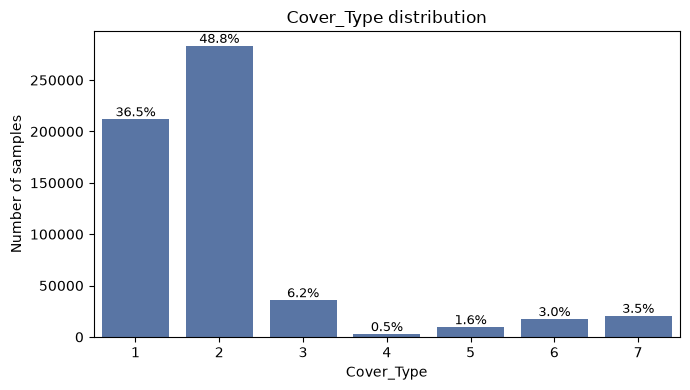

In [8]:
class_counts = (
    df.groupBy(LABEL).count()
      .orderBy(LABEL)
      .toPandas()
)
class_counts["pct"] = 100 * class_counts["count"] / class_counts["count"].sum()

imbalance_ratio = class_counts["count"].max() / class_counts["count"].min()
print(f"Imbalance ratio (max/min): {imbalance_ratio:.1f} : 1")

_, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=class_counts, x=LABEL, y="count", ax=ax, color="#4C72B0")
ax.set_title(f"Cover_Type distribution")
ax.set_xlabel("Cover_Type")
ax.set_ylabel("Number of samples")
for i, row in class_counts.iterrows():
    ax.text(i, row["count"], f"{row['pct']:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### 5.2 Global descriptive statistics

In [9]:
global_stats = (
    df.select(QUANTITATIVE)
      .summary()
      .toPandas()
      .set_index("summary")
      .T
      .astype(float)
      .round(2)
)

global_stats

summary,count,mean,stddev,min,25%,50%,75%,max
Elevation,581012.0,2959.37,279.98,1859.0,2809.0,2996.0,3163.0,3858.0
Aspect,581012.0,155.66,111.91,0.0,58.0,127.0,260.0,360.0
Slope,581012.0,14.10,7.49,0.0,9.0,13.0,18.0,66.0
Horizontal_Distance_To_Hydrology,581012.0,269.43,212.55,0.0,108.0,218.0,384.0,1397.0
Vertical_Distance_To_Hydrology,581012.0,46.42,58.30,-173.0,7.0,30.0,69.0,601.0
Horizontal_Distance_To_Roadways,581012.0,2350.15,1559.25,0.0,1106.0,1997.0,3328.0,7117.0
Hillshade_9am,581012.0,212.15,26.77,0.0,198.0,218.0,231.0,254.0
Hillshade_Noon,581012.0,223.32,19.77,0.0,213.0,226.0,237.0,254.0
Hillshade_3pm,581012.0,142.53,38.27,0.0,119.0,143.0,168.0,254.0
Horizontal_Distance_To_Fire_Points,581012.0,1980.29,1324.20,0.0,1024.0,1710.0,2550.0,7173.0


### 5.3 Per-class statistics

In [10]:
per_class = (
    df.groupBy(LABEL)
      .agg(*[e for c in QUANTITATIVE
             for e in (F.round(F.mean(c), 1).alias(f"{c}_mean"),
                       F.round(F.stddev(c), 1).alias(f"{c}_std"))])
      .orderBy(LABEL)
      .toPandas()
      .set_index(LABEL)
      .T
)

per_class

Cover_Type,1,2,3,4,5,6,7
Elevation_mean,3128.6,2920.9,2394.5,2223.9,2787.4,2419.2,3361.9
Elevation_std,157.8,186.6,196.7,102.5,96.6,188.8,106.9
Aspect_mean,156.1,152.1,176.4,137.1,139.3,180.5,153.2
Aspect_std,116.7,107.7,107.6,87.0,91.6,133.8,110.6
Slope_mean,13.1,13.6,20.8,18.5,16.6,19.0,14.3
Slope_std,6.8,7.1,9.0,9.3,8.2,8.0,7.5
Horizontal_Distance_To_Hydrology_mean,270.6,279.9,210.3,106.9,212.4,159.9,357.0
Horizontal_Distance_To_Hydrology_std,216.7,210.3,142.2,139.7,179.4,124.5,295.1
Vertical_Distance_To_Hydrology_mean,42.2,45.9,62.4,41.2,50.6,45.4,69.5
Vertical_Distance_To_Hydrology_std,56.6,57.5,58.9,59.1,57.8,47.0,79.9


Of the ten quantitative features, `Elevation` separates the classes better than any other, so
it is worth looking at before any model is trained. The plot below shows each class as a band
of elevations; the classes whose band sits closest to a much larger one are the ones the models
score worst on. Blackard & Dean (1999) and Tavakol Sadrabadi & Innocente (2023) report the same
feature as the most discriminative.

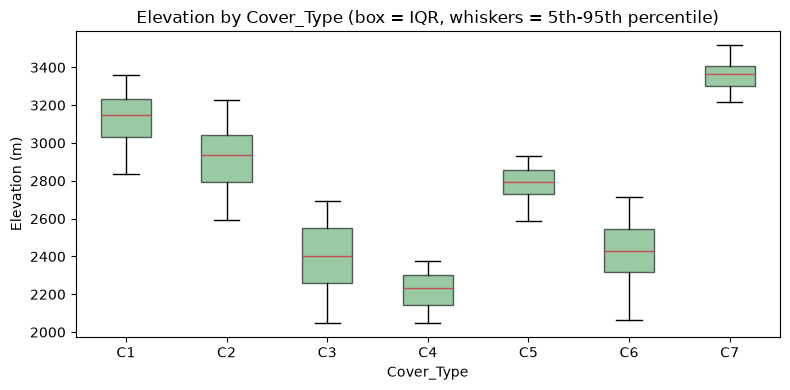

In [11]:
QS   = [0.05, 0.25, 0.5, 0.75, 0.95]
KEYS = ["whislo", "q1", "med", "q3", "whishi"]

elev_by_class = (
    df.groupBy(LABEL)
      .agg(F.percentile_approx("Elevation", QS).alias("q"))
      .orderBy(LABEL)
      .toPandas()
)

stats = [dict(zip(KEYS, r["q"]), label=CLASSES[r[LABEL] - 1])
         for _, r in elev_by_class.iterrows()]

_, ax = plt.subplots(figsize=(8, 4))
ax.bxp(stats, showfliers=False, patch_artist=True,
       boxprops={"facecolor": "#55A868", "alpha": 0.6},
       medianprops={"color": "#C44E52"})
ax.set_title("Elevation by Cover_Type (box = IQR, whiskers = 5th-95th percentile)")
ax.set_xlabel("Cover_Type")
ax.set_ylabel("Elevation (m)")
plt.tight_layout()
plt.show()

Each row belongs to exactly one of the four wilderness areas, so the values in each row below
add up to 100%. The areas constrain the label rather than merely shifting probabilities: cover
type 4 occurs only in area 4, area 2 contains no type 3, 4, 5 or 6, and area 4 contains no type
1, 5 or 7. Together with elevation this explains which classes the models confuse. Type 5
shares both its elevation band and its two wilderness areas with the two largest classes, and
it has the lowest F1 in every run; type 4 is the rarest class of all, yet it is confined to a
single area at the bottom of the elevation range, and on recall it outscores type 6, which is
six times more frequent, in eleven of the twelve runs.

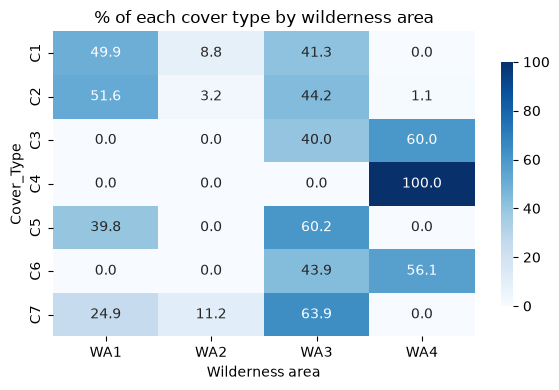

In [12]:
wilderness_by_class = (
    df.groupBy(LABEL)
      .agg(*[F.round(100 * F.mean(c), 1).alias(f"WA{i}")
             for i, c in enumerate(WILDERNESS, start=1)])
      .orderBy(LABEL)
      .toPandas()
      .set_index(LABEL)
)
wilderness_by_class.index = CLASSES

_, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(wilderness_by_class, annot=True, fmt=".1f", cmap="Blues",
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("% of each cover type by wilderness area")
ax.set_xlabel("Wilderness area"); ax.set_ylabel("Cover_Type")
plt.tight_layout(); plt.show()

### 5.4 Correlation of quantitative features

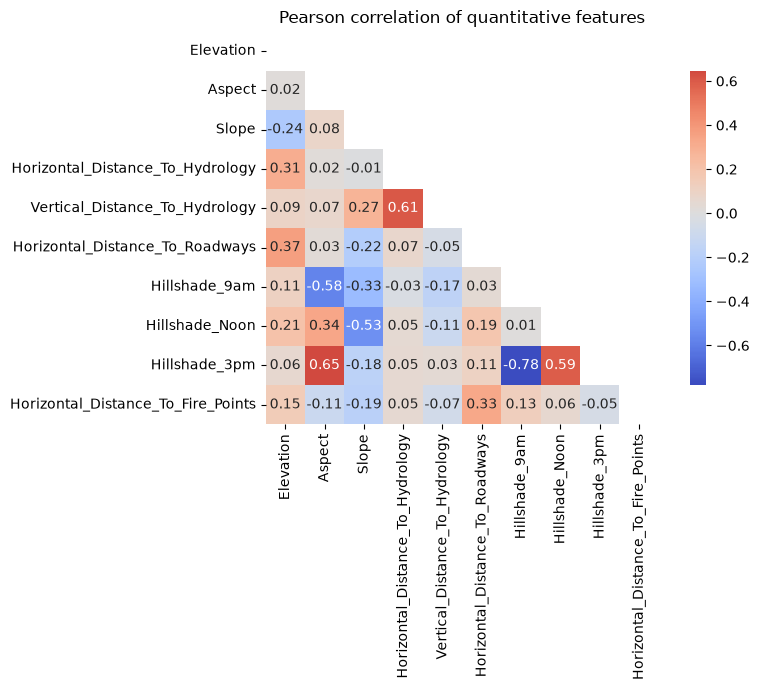

In [13]:
assembler = VectorAssembler(inputCols=QUANTITATIVE, outputCol="_quant_vec")
vec_df = assembler.transform(df.select(QUANTITATIVE))
corr_pd = pd.DataFrame(
    Correlation.corr(vec_df, "_quant_vec", "pearson").head()[0].toArray(),
    index=QUANTITATIVE, columns=QUANTITATIVE,
)

mask = np.triu(np.ones_like(corr_pd, dtype=bool))

_, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_pd, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Pearson correlation of quantitative features")
plt.tight_layout()
plt.show()

## 6. Preprocessing

In [14]:
df_ml = (
    VectorAssembler(inputCols=FEATURE_COLS, outputCol="features")
    .transform(df.withColumn("label", F.col(LABEL) - 1))
    .select("features", "label")
    .cache()
)

label_range = df_ml.agg(F.min("label"), F.max("label")).first()
print(f"Label range after remap: {label_range[0]}..{label_range[1]}")

df.unpersist();

Label range after remap: 0..6


In [15]:
train_df, test_df = df_ml.randomSplit([TRAIN_FRAC, 1 - TRAIN_FRAC], seed=SEED)
train_df.cache()
test_df.cache()

print(f"Train rows: {train_df.count():,}")
print(f"Test  rows: {test_df.count():,}")

Train rows: 464,836
Test  rows: 116,176


In [16]:
counts = train_df.groupBy("label").count().toPandas().set_index("label")["count"]
min_count = int(counts.min())
print(f"Smallest training class: {min_count:,} rows")

undersample_fractions = {int(label): min_count / n for label, n in counts.items()}
train_bal = train_df.sampleBy("label", fractions=undersample_fractions, seed=SEED).cache()

bal_counts = train_bal.groupBy("label").count().orderBy("label").toPandas()
print(f"\nBalanced training rows: {bal_counts['count'].sum():,}")
print("Balanced training distribution:")
print(bal_counts.to_string(index=False))

df_ml.unpersist();

Smallest training class: 2,212 rows

Balanced training rows: 15,528
Balanced training distribution:
 label  count
     0   2276
     1   2213
     2   2210
     3   2212
     4   2265
     5   2106
     6   2246


## 7. Models and evaluation

In [17]:
gbt = GBTClassifier(labelCol="label", featuresCol="features",
                    maxIter=20, maxDepth=5, seed=SEED)

mlp = MultilayerPerceptronClassifier(labelCol="label", featuresCol="scaledFeatures",
                                     layers=[len(FEATURE_COLS), 32, N_CLASSES],
                                     maxIter=100, seed=SEED)

MODELS = {
    "Decision Tree": DecisionTreeClassifier(
        labelCol="label", featuresCol="features", maxDepth=15, seed=SEED),

    "Random Forest": RandomForestClassifier(
        labelCol="label", featuresCol="features", numTrees=50, maxDepth=15, seed=SEED),

    "GBT": OneVsRest(labelCol="label", featuresCol="features", classifier=gbt),

    "MLP": Pipeline(stages=[
        StandardScaler(inputCol="features", outputCol="scaledFeatures",
                       withMean=True, withStd=True),
        mlp,
    ]),
}

In [18]:
RESULTS = {}

def evaluate(name, model, test):
    cm_long = model.transform(test).groupBy("label", "prediction").count().toPandas()
    cm = (cm_long
          .pivot(index="label", columns="prediction", values="count")
          .reindex(index=range(N_CLASSES), columns=range(N_CLASSES))
          .fillna(0).astype(int))
    cm_v = cm.values.astype(float)

    tp = np.diag(cm_v)
    fp = cm_v.sum(axis=0) - tp
    fn = cm_v.sum(axis=1) - tp
    support = tp + fn
    prec = np.nan_to_num(tp / (tp + fp))
    rec  = np.nan_to_num(tp / support)
    f1c  = np.nan_to_num(2 * prec * rec / (prec + rec))

    total = cm_v.sum()
    acc = tp.sum() / total
    f1w = (support * f1c).sum() / total

    per_class = pd.DataFrame(
        {"precision": prec.round(3), "recall": rec.round(3), "f1": f1c.round(3)},
        index=CLASSES,
    )

    RESULTS[name] = {"accuracy": acc, "weighted_f1": f1w,
                     "per_class": per_class, "cm": cm}

    print(f"{name}:  accuracy={acc:.4f}   weighted_F1={f1w:.4f}\n")
    print(per_class.to_string())

    cm_norm = cm_v / support.clip(min=1)[:, None]
    _, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES,
                ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(f"{name} (row-normalized)")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout(); plt.show()

## 8. Balanced training

Decision Tree (balanced):  accuracy=0.6593   weighted_F1=0.6746

    precision  recall     f1
C1      0.694   0.683  0.688
C2      0.781   0.591  0.673
C3      0.754   0.744  0.749
C4      0.531   0.907  0.669
C5      0.163   0.909  0.276
C6      0.487   0.795  0.604
C7      0.518   0.937  0.667


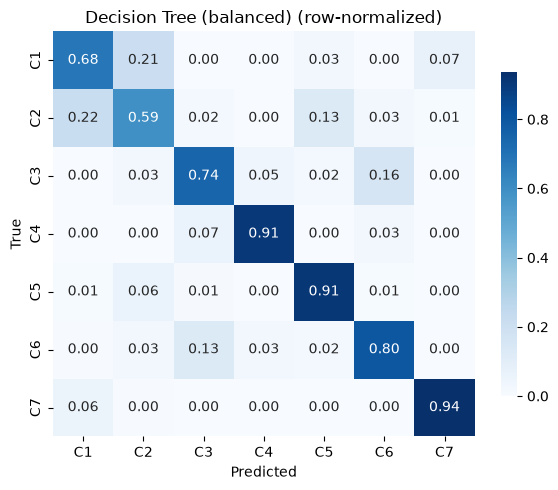

In [19]:
evaluate("Decision Tree (balanced)", MODELS["Decision Tree"].fit(train_bal), test_df)

Random Forest (balanced):  accuracy=0.6768   weighted_F1=0.6941

    precision  recall     f1
C1      0.708   0.740  0.724
C2      0.844   0.579  0.687
C3      0.751   0.756  0.754
C4      0.450   0.951  0.611
C5      0.160   0.933  0.273
C6      0.481   0.815  0.605
C7      0.502   0.953  0.658


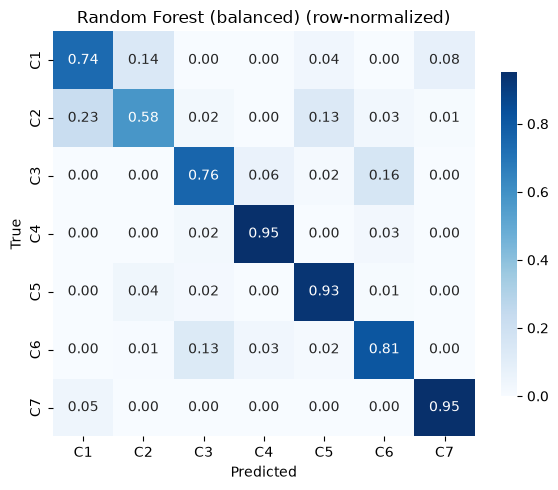

In [20]:
evaluate("Random Forest (balanced)", MODELS["Random Forest"].fit(train_bal), test_df)

GBT (balanced):  accuracy=0.6208   weighted_F1=0.6463

    precision  recall     f1
C1      0.689   0.687  0.688
C2      0.814   0.517  0.633
C3      0.726   0.697  0.711
C4      0.432   0.955  0.595
C5      0.116   0.901  0.206
C6      0.425   0.756  0.544
C7      0.422   0.938  0.583


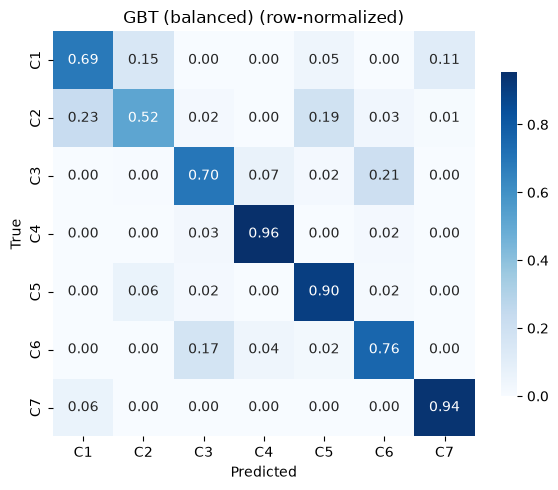

In [21]:
evaluate("GBT (balanced)", MODELS["GBT"].fit(train_bal), test_df)

MLP (balanced):  accuracy=0.6657   weighted_F1=0.6827

    precision  recall     f1
C1      0.708   0.702  0.705
C2      0.811   0.606  0.694
C3      0.699   0.679  0.689
C4      0.340   0.901  0.493
C5      0.170   0.879  0.286
C6      0.415   0.684  0.517
C7      0.481   0.940  0.637


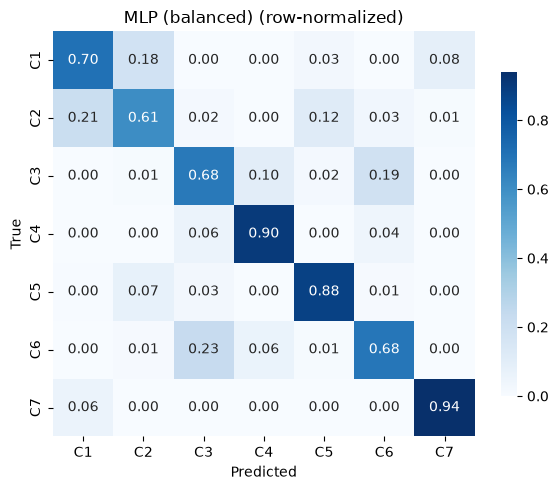

In [22]:
evaluate("MLP (balanced)", MODELS["MLP"].fit(train_bal), test_df)

## 9. Hyperparameter tuning

In [23]:
_eval_f1 = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1")

def tune_model(name, estimator, param_grid, train, test):
    cv = CrossValidator(
        estimator=estimator,
        estimatorParamMaps=param_grid,
        evaluator=_eval_f1,
        numFolds=3,
        parallelism=2,
        seed=SEED,
    )
    cv_model = cv.fit(train)

    scores = pd.DataFrame({
        "params": [", ".join(f"{p.name}={v}" for p, v in pm.items())
                   for pm in cv_model.getEstimatorParamMaps()],
        "cv_f1": [round(m, 4) for m in cv_model.avgMetrics],
    }).sort_values("cv_f1", ascending=not _eval_f1.isLargerBetter())

    print(f"{name} -- {len(param_grid)} param combo(s) x {cv.getNumFolds()} folds", flush=True)
    print(scores.to_string(index=False) + "\n", flush=True)

    evaluate(name, cv_model.bestModel, test)

Decision Tree (tuned, balanced) -- 3 param combo(s) x 3 folds
     params  cv_f1
maxDepth=20 0.7793
maxDepth=15 0.7778
maxDepth=10 0.7525

Decision Tree (tuned, balanced):  accuracy=0.6741   weighted_F1=0.6860

    precision  recall     f1
C1      0.695   0.691  0.693
C2      0.783   0.616  0.689
C3      0.749   0.757  0.753
C4      0.531   0.901  0.668
C5      0.190   0.899  0.314
C6      0.504   0.779  0.612
C7      0.540   0.933  0.684


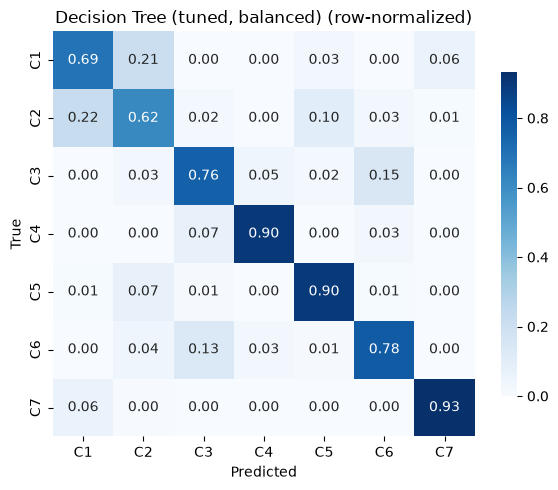

In [24]:
dt_grid = (ParamGridBuilder()
           .addGrid(MODELS["Decision Tree"].maxDepth, [10, 15, 20])
           .build())
tune_model("Decision Tree (tuned, balanced)", MODELS["Decision Tree"], dt_grid,
           train_bal, test_df)

Random Forest (tuned, balanced) -- 6 param combo(s) x 3 folds
                   params  cv_f1
numTrees=100, maxDepth=25 0.8364
 numTrees=50, maxDepth=25 0.8330
numTrees=100, maxDepth=20 0.8329
 numTrees=50, maxDepth=20 0.8285
numTrees=100, maxDepth=15 0.8150
 numTrees=50, maxDepth=15 0.8109

Random Forest (tuned, balanced):  accuracy=0.7266   weighted_F1=0.7393

    precision  recall     f1
C1      0.750   0.757  0.754
C2      0.857   0.663  0.748
C3      0.759   0.786  0.772
C4      0.462   0.959  0.623
C5      0.215   0.935  0.350
C6      0.526   0.835  0.646
C7      0.537   0.959  0.688


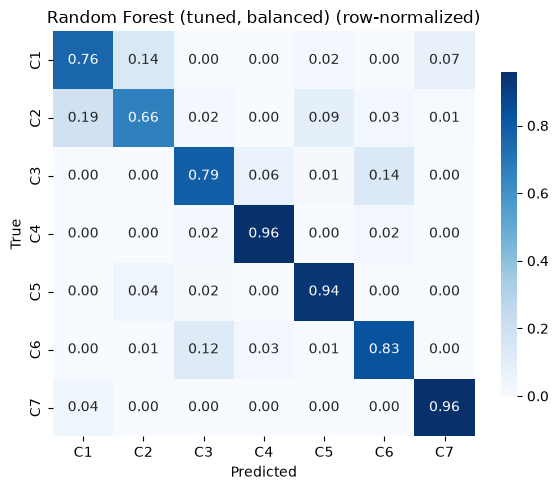

In [25]:
rf_grid = (ParamGridBuilder()
           .addGrid(MODELS["Random Forest"].numTrees, [50, 100])
           .addGrid(MODELS["Random Forest"].maxDepth, [15, 20, 25])
           .build())
tune_model("Random Forest (tuned, balanced)", MODELS["Random Forest"], rf_grid,
           train_bal, test_df)

GBT (tuned, balanced) -- 4 param combo(s) x 3 folds
                params  cv_f1
maxDepth=5, maxIter=20 0.7738
maxDepth=5, maxIter=10 0.7514
maxDepth=3, maxIter=20 0.7145
maxDepth=3, maxIter=10 0.6924

GBT (tuned, balanced):  accuracy=0.6208   weighted_F1=0.6463

    precision  recall     f1
C1      0.689   0.687  0.688
C2      0.814   0.517  0.633
C3      0.726   0.697  0.711
C4      0.432   0.955  0.595
C5      0.116   0.901  0.206
C6      0.425   0.756  0.544
C7      0.422   0.938  0.583


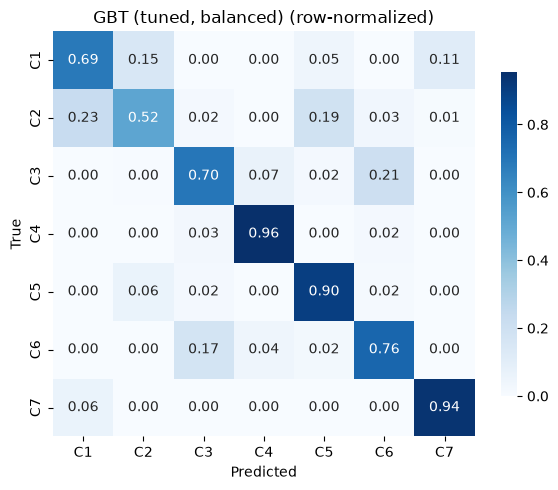

In [26]:
gbt_grid = (ParamGridBuilder()
            .addGrid(gbt.maxDepth, [3, 5])
            .addGrid(gbt.maxIter, [10, 20])
            .build())
tune_model("GBT (tuned, balanced)", MODELS["GBT"], gbt_grid, train_bal, test_df)

MLP (tuned, balanced) -- 4 param combo(s) x 3 folds
                              params  cv_f1
layers=[54, 128, 64, 7], maxIter=300 0.8278
layers=[54, 128, 64, 7], maxIter=200 0.8183
 layers=[54, 64, 32, 7], maxIter=300 0.8162
 layers=[54, 64, 32, 7], maxIter=200 0.8155

MLP (tuned, balanced):  accuracy=0.7439   weighted_F1=0.7530

    precision  recall     f1
C1      0.759   0.751  0.755
C2      0.842   0.702  0.766
C3      0.798   0.794  0.796
C4      0.569   0.951  0.712
C5      0.259   0.937  0.406
C6      0.547   0.846  0.665
C7      0.574   0.954  0.717


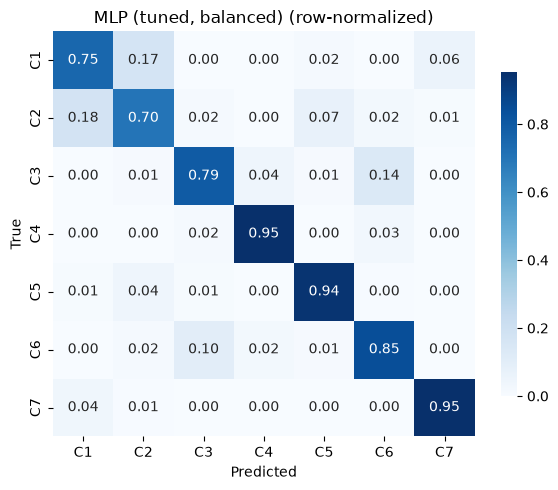

In [27]:
n_feat = len(FEATURE_COLS)
mlp_grid = (ParamGridBuilder()
            .addGrid(mlp.layers, [[n_feat, 64, 32, N_CLASSES],
                                  [n_feat, 128, 64, N_CLASSES]])
            .addGrid(mlp.maxIter, [200, 300])
            .build())
tune_model("MLP (tuned, balanced)", MODELS["MLP"], mlp_grid, train_bal, test_df)

## 10. Imbalanced training

Decision Tree (imbalanced):  accuracy=0.8508   weighted_F1=0.8483

    precision  recall     f1
C1      0.866   0.825  0.845
C2      0.841   0.905  0.872
C3      0.878   0.818  0.847
C4      0.871   0.705  0.779
C5      0.811   0.341  0.480
C6      0.715   0.627  0.668
C7      0.909   0.866  0.887


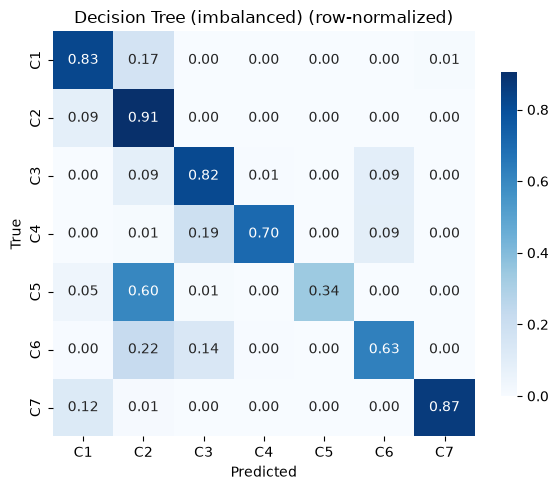

In [28]:
evaluate("Decision Tree (imbalanced)", MODELS["Decision Tree"].fit(train_df), test_df)

Random Forest (imbalanced):  accuracy=0.7905   weighted_F1=0.7825

    precision  recall     f1
C1      0.786   0.765  0.775
C2      0.786   0.857  0.820
C3      0.766   0.884  0.821
C4      0.898   0.645  0.751
C5      0.934   0.121  0.214
C6      0.910   0.321  0.474
C7      0.931   0.703  0.801


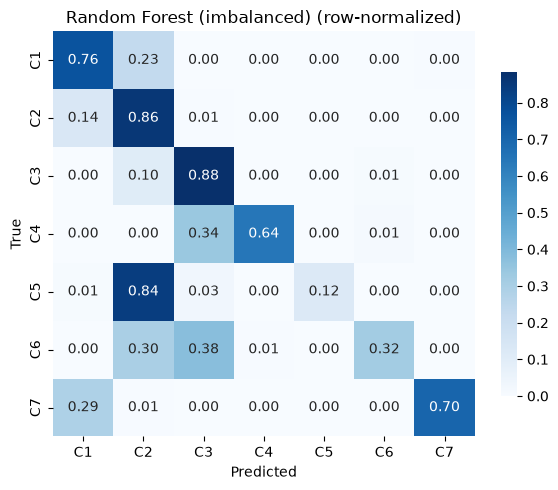

In [29]:
evaluate("Random Forest (imbalanced)", MODELS["Random Forest"].fit(train_df), test_df)

GBT (imbalanced):  accuracy=0.7646   weighted_F1=0.7579

    precision  recall     f1
C1      0.755   0.741  0.748
C2      0.776   0.829  0.801
C3      0.731   0.852  0.787
C4      0.832   0.686  0.752
C5      0.869   0.136  0.235
C6      0.615   0.340  0.438
C7      0.846   0.636  0.726


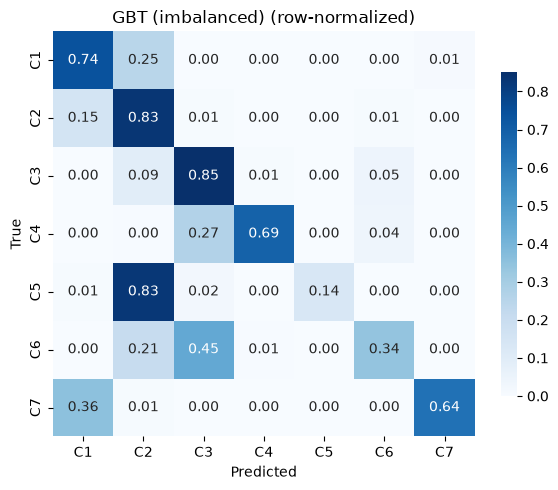

In [30]:
evaluate("GBT (imbalanced)", MODELS["GBT"].fit(train_df), test_df)

MLP (imbalanced):  accuracy=0.7846   weighted_F1=0.7795

    precision  recall     f1
C1      0.788   0.766  0.777
C2      0.803   0.846  0.824
C3      0.712   0.815  0.760
C4      0.557   0.329  0.414
C5      0.703   0.176  0.282
C6      0.554   0.410  0.471
C7      0.807   0.732  0.768


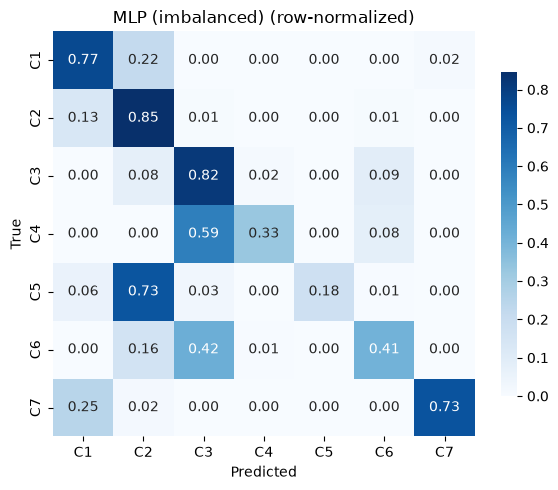

In [31]:
evaluate("MLP (imbalanced)", MODELS["MLP"].fit(train_df), test_df)

## 11. Results and Discussion

In [32]:
summary = pd.DataFrame({
    name: {
        "accuracy":        round(r["accuracy"], 3),
        "weighted_F1":     round(r["weighted_f1"], 3),
        "macro_F1":        round(r["per_class"]["f1"].mean(), 3),
        "macro_precision": round(r["per_class"]["precision"].mean(), 3),
        "macro_recall":    round(r["per_class"]["recall"].mean(), 3),
    }
    for name, r in RESULTS.items()
}).T.sort_index()

summary

,accuracy,weighted_F1,macro_F1,macro_precision,macro_recall
Decision Tree (balanced),0.659,0.675,0.618,0.561,0.795
Decision Tree (imbalanced),0.851,0.848,0.768,0.842,0.727
"Decision Tree (tuned, balanced)",0.674,0.686,0.630,0.570,0.797
GBT (balanced),0.621,0.646,0.566,0.518,0.779
GBT (imbalanced),0.765,0.758,0.641,0.775,0.603
"GBT (tuned, balanced)",0.621,0.646,0.566,0.518,0.779
MLP (balanced),0.666,0.683,0.574,0.518,0.770
MLP (imbalanced),0.785,0.780,0.614,0.703,0.582
"MLP (tuned, balanced)",0.744,0.753,0.688,0.621,0.848
Random Forest (balanced),0.677,0.694,0.616,0.557,0.818


All twelve runs are scored on the same test set, which is left imbalanced. This means the runs
are not all comparable with each other. A model trained on the imbalanced set sees a test set
with the same skew, so it scores well on any metric weighted by class frequency. The Decision
Tree trained this way has the highest accuracy (0.851) and weighted F1 (0.848) of the whole
study, but it correctly identifies only about a third of class 5. For this reason we compare
models within a training regime, and we report per-class metrics next to accuracy.

The same thing happens with every model. Training on the real frequencies raises accuracy by
0.11 to 0.19 and lowers macro-recall by 0.07 to 0.20. These averages hide how bad it gets for
the rare classes. On balanced data every model identifies 88% to 93% of class 5. On the real
frequencies the same models identify between 12% and 34%. The Random Forest is the worst case:
it drops from 0.933 to 0.121. Section 5 anticipated which classes these would be. Class 5
shares its elevation band and both its wilderness areas with class 2, which is thirty times
larger, and class 6 stands in the same relation to class 3. Class 4 is the rarest class in the
dataset, yet it is confined to a single wilderness area at the bottom of the elevation range,
and on recall it outscores class 6, which is six times more frequent, in eleven of the twelve
runs.

The trade also works the other way. Before tuning, macro-precision on balanced data is only
0.52 to 0.56, because the models predict the rare classes too often. On the real frequencies it
rises to 0.70 to 0.86. Balancing does not remove the problem. It trades precision for recall on
the rare classes.

On the balanced training set, tuning helped some models much more than others. Weighted F1 rose
by 0.070 for the MLP and by 0.045 for the Random Forest. The Decision Tree gained only 0.011,
and GBT gained nothing at all, because its search chose the same parameters it started with.
The MLP is the clearest case: its macro-precision rose from 0.518 to 0.621 and its macro-F1
from 0.574 to 0.688, against at most 0.038 for any other model on those two measures. All four
searches picked a value at the edge of their grid, so larger settings might still help.

Two models come out ahead. Among the eight models trained on the balanced set, the tuned MLP is
the best on all five measures, and the tuned Random Forest is close behind. On weighted F1 the
gap is small, 0.753 against 0.739, and on macro-recall it is smaller still, 0.848 against
0.842. It is wider on macro-F1, 0.688 against 0.654, and that is the measure which counts every
class equally. These are also the two models that tuning improved most: the Decision Tree
gained little even with a deeper tree, and GBT was the weakest in every regime.

## 12. Shutdown

In [33]:
spark.stop()